# 06 — Reserva y reporte final

## Objetivo

Este notebook constituye la etapa final del proyecto de estimación de **Loss Incurred**.

A partir de los resultados obtenidos en el backtesting y en la evaluación de modelos, se aplicará el método seleccionado para cada escenario sobre la información disponible en la fecha final de valuación.

Los objetivos son:

1. Recuperar el método seleccionado para cada escenario.
2. Construir la fotografía del triángulo disponible en la fecha final de valuación.
3. Estimar el Loss Incurred ultimate de los períodos todavía inmaduros.
4. Calcular la reserva como la diferencia entre el ultimate estimado y el Loss Incurred observado.
5. Analizar la composición de la reserva por período de ocurrencia.
6. Comparar los resultados obtenidos entre los escenarios creciente, decreciente y mixto.
7. Documentar los principales supuestos y limitaciones del ejercicio.

La estimación de reserva para cada período de ocurrencia $i$ se define como:

$$
\widehat{R}_i =
\widehat{U}_i - LI_i^{obs}
$$

donde:

- $\widehat{R}_i$: reserva estimada;
- $\widehat{U}_i$: Loss Incurred ultimate estimado;
- $LI_i^{obs}$: Loss Incurred acumulado observado a la fecha de valuación.

La reserva total se obtiene mediante:

$$
\widehat{R}_{total} = \sum_i \widehat{R}_i
$$

El objetivo de esta etapa **no es volver a seleccionar modelos**, sino utilizar la evidencia obtenida durante el backtesting para realizar una valuación final consistente.

## Configuración del entorno

In [25]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales


## 1. Métodos seleccionados

La selección de métodos se realizó previamente mediante el esquema de backtesting.

Por lo tanto, en esta etapa la selección se considera **cerrada**. La valuación final utilizará exclusivamente los métodos elegidos en el Notebook 05, evitando seleccionar un modelo a partir de su desempeño sobre la valuación final.

Esto mantiene separadas las etapas de:

- entrenamiento;
- evaluación;
- selección;
- valuación final.

In [26]:
SELECTED_METHODS = {
    "creciente": "VW_all_none",
    "decreciente": "VW_all_none",
    "mixto": "VW_all_none",
}

selected_methods = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "method_name": method,
            "method_family": "development",
        }
        for scenario, method in SELECTED_METHODS.items()
    ]
)

display(selected_methods)

,scenario,method_name,method_family
0,creciente,VW_all_none,development
1,decreciente,VW_all_none,development
2,mixto,VW_all_none,development


### Selección utilizada en la valuación final

El backtesting realizado en las etapas anteriores seleccionó la especificación
de Desarrollo `VW_all_none` para los tres escenarios.

La selección se considera fija antes de realizar la valuación final. Por tanto,
los resultados obtenidos en esta etapa no se utilizan para volver a seleccionar
o modificar el método.

La especificación seleccionada utiliza factores de desarrollo estimados mediante
promedios ponderados por volumen sobre toda la historia disponible, sin aplicar
ventanas móviles ni exclusiones adicionales.

Esta elección permite mantener una correspondencia directa entre la evidencia
obtenida durante el backtesting y la metodología utilizada para estimar la
reserva final.

## 2. Configuración de la valuación final

La valuación final reproduce el procedimiento que se utilizaría al cierre del
período de observación.

Para cada escenario se separan dos conjuntos:

- **cohortes maduras:** ya alcanzaron `dev_M` y pueden utilizarse para estimar
  los factores de desarrollo;
- **cohortes inmaduras:** todavía no alcanzan `dev_M` y requieren una
  estimación de su Loss Incurred ultimate.

La metodología seleccionada es `VW_all_none`, equivalente a:

- método de agregación: `VW`;
- ventana histórica: `all`;
- exclusión: `none`.

Los factores se estiman exclusivamente con cohortes maduras. Posteriormente,
se construye el CDF correspondiente a la edad actual de cada cohorte inmadura
y se estima:

$$
\widehat{U}_i = LI_i^{obs}\times CDF_{d_i}
$$

Finalmente:

$$
\widehat{R}_i =
\widehat{U}_i-LI_i^{obs}.
$$

El verdadero Loss Incurred a `dev_M`, disponible por tratarse de un experimento
simulado, no participa en este procedimiento.

In [27]:
from src.simulation.config import SimulationConfig, SCENARIO_CONFIGS
from src.simulation.generator import simulate_all_scenarios
from src.experiment.snapshots import (
    build_train_prediction_snapshots,
    reveal_targets,
)
from src.models.development import run_development_alternative

FINAL_VALUATION_PERIOD = pd.Period("2025-12", freq="M")
FINAL_ALTERNATIVE = ("VW", "all", "none")

## 3. Construcción de la valuación final

Para cada escenario se construye una fotografía de la información disponible
en `2025-12`.

La misma infraestructura utilizada durante el backtesting permite separar
automáticamente:

- las cohortes maduras disponibles para estimar los factores;
- las cohortes inmaduras que requieren una estimación de ultimate.

Esta separación es particularmente importante porque reproduce las condiciones
de una valuación real: el modelo solo puede utilizar información que ya sería
conocida en la fecha de corte.

A diferencia del backtesting, después de generar las predicciones **no se
revelará el target para construir la reserva**. La valuación se realizará
exclusivamente con la información observable.

### Función de valuación

La función siguiente encapsula el flujo completo para cada escenario: construye los snapshots disponibles a la fecha de corte, estima los factores con las cohortes maduras, proyecta el ultimate de las cohortes inmaduras y calcula la reserva correspondiente.

In [28]:
def run_final_valuation(
    scenario_data,
    scenario,
    valuation_period=FINAL_VALUATION_PERIOD,
):
    """
    Ejecuta la valuación final de un escenario utilizando
    el método seleccionado previamente mediante backtesting.
    """
    dev_M = SCENARIO_CONFIGS[scenario].dev_M

    # --------------------------------------------------------
    # 1. Snapshots disponibles en la fecha de valuación
    # --------------------------------------------------------

    train_snapshot, prediction_snapshot = (
        build_train_prediction_snapshots(
            df=scenario_data,
            scenario=scenario,
            valuation_period=valuation_period,
            final_period=valuation_period,
        )
    )

    # --------------------------------------------------------
    # 2. Ajuste del método seleccionado y predicción
    # --------------------------------------------------------

    factors, predictions = run_development_alternative(
        train_snapshot=train_snapshot,
        prediction_snapshot=prediction_snapshot,
        alternative=FINAL_ALTERNATIVE,
        dev_M=dev_M,
    )

    # --------------------------------------------------------
    # 3. Ultimate y reserva
    # --------------------------------------------------------

    results = predictions.rename(
        columns={
            "observed_amount": "observed_li",
            "prediction": "estimated_ultimate",
        }
    ).copy()

    results["reserve"] = (
        results["estimated_ultimate"]
        - results["observed_li"]
    )

    results["reserve_pct"] = (
        results["reserve"]
        / results["estimated_ultimate"]
    )

    # --------------------------------------------------------
    # 4. Validaciones
    # --------------------------------------------------------

    assert results["observed_li"].gt(0).all()
    assert results["estimated_ultimate"].gt(0).all()
    assert results["method_name"].eq("VW_all_none").all()

    return {
        "train_snapshot": train_snapshot,
        "prediction_snapshot": prediction_snapshot,
        "factors": factors,
        "results": results,
    }

In [29]:
simulation_config = SimulationConfig()

scenario_data = simulate_all_scenarios(
    config=simulation_config
)

for scenario, data in scenario_data.items():
    print(
        f"{scenario:<12} | "
        f"{len(data):>6,} filas | "
        f"dev_M = {SCENARIO_CONFIGS[scenario].dev_M}"
    )

creciente    |  8,052 filas | dev_M = 60
decreciente  |  6,468 filas | dev_M = 48
mixto        |  6,468 filas | dev_M = 48


### Ejecución de la valuación

In [30]:
final_valuations = {}

for scenario, data in scenario_data.items():

    final_valuations[scenario] = run_final_valuation(
        scenario_data=data,
        scenario=scenario,
    )

    results = final_valuations[scenario]["results"]

    print("=" * 70)
    print(f"ESCENARIO: {scenario.upper()}")
    print("=" * 70)

    print(
        f"Cohortes inmaduras:       "
        f"{len(results):,}"
    )

    print(
        f"Loss Incurred observado:  "
        f"${results['observed_li'].sum():,.2f}"
    )

    print(
        f"Ultimate estimado:         "
        f"${results['estimated_ultimate'].sum():,.2f}"
    )

    print(
        f"Reserva estimada:          "
        f"${results['reserve'].sum():,.2f}"
    )

    print()

ESCENARIO: CRECIENTE
Cohortes inmaduras:       60
Loss Incurred observado:  $71,564,980.22
Ultimate estimado:         $82,806,622.65
Reserva estimada:          $11,241,642.43

ESCENARIO: DECRECIENTE
Cohortes inmaduras:       48
Loss Incurred observado:  $72,034,997.46
Ultimate estimado:         $67,004,058.15
Reserva estimada:          $-5,030,939.31

ESCENARIO: MIXTO
Cohortes inmaduras:       48
Loss Incurred observado:  $68,608,523.05
Ultimate estimado:         $68,474,553.35
Reserva estimada:          $-133,969.70



### Resumen de la valuación

In [31]:
valuation_summary = []

for scenario, valuation in final_valuations.items():

    results = valuation["results"]

    observed = results["observed_li"].sum()
    ultimate = results["estimated_ultimate"].sum()
    reserve = results["reserve"].sum()

    valuation_summary.append(
        {
            "scenario": scenario,
            "n_immature": len(results),
            "observed_li": observed,
            "estimated_ultimate": ultimate,
            "reserve": reserve,
            "reserve_pct_ultimate": reserve / ultimate,
            "reserve_pct_observed": reserve / observed,
        }
    )

valuation_summary = pd.DataFrame(valuation_summary)

display(
    valuation_summary.style.hide(axis="index").format(
        {
            "observed_li": "${:,.0f}",
            "estimated_ultimate": "${:,.0f}",
            "reserve": "${:,.0f}",
            "reserve_pct_ultimate": "{:.2%}",
            "reserve_pct_observed": "{:.2%}",
        }
    )
)

scenario,n_immature,observed_li,estimated_ultimate,reserve,reserve_pct_ultimate,reserve_pct_observed
creciente,60,"$71,564,980","$82,806,623","$11,241,642",13.58%,15.71%
decreciente,48,"$72,034,997","$67,004,058","$-5,030,939",-7.51%,-6.98%
mixto,48,"$68,608,523","$68,474,553","$-133,970",-0.20%,-0.20%


### Interpretación de la valuación

Los resultados muestran comportamientos claramente distintos entre los tres
patrones de desarrollo.

**Escenario creciente.**  
La reserva estimada es positiva y asciende aproximadamente a $11.24 millones.
El Loss Incurred observado de las cohortes inmaduras todavía se encuentra por
debajo del nivel esperado a madurez, por lo que el método proyecta desarrollo
adicional.

**Escenario decreciente.**  
La reserva estimada es negativa, aproximadamente -$5.03 millones. Este resultado
no representa una inconsistencia: el escenario fue diseñado para comenzar con
niveles de Loss Incurred superiores al definitivo y posteriormente ajustarse
hacia abajo. Por tanto, la estimación representa una liberación esperada del
Loss Incurred actualmente reconocido.

**Escenario mixto.**  
La reserva neta es cercana a cero, aproximadamente -$0.13 millones. Sin embargo,
este resultado agregado debe interpretarse con cautela. El escenario combina
una fase de crecimiento temprano con una fase posterior de disminución, por lo
que pueden coexistir cohortes con desarrollo pendiente positivo y negativo.

En consecuencia, una reserva neta reducida no implica necesariamente ausencia
de desarrollo pendiente, ya que puede ser consecuencia de la compensación entre
cohortes situadas en distintas etapas de desarrollo.

## 4. Composición de la reserva

La reserva agregada puede ocultar comportamientos distintos entre cohortes. Por ello, se analiza su distribución por período de ocurrencia y se separan los movimientos positivos y negativos.

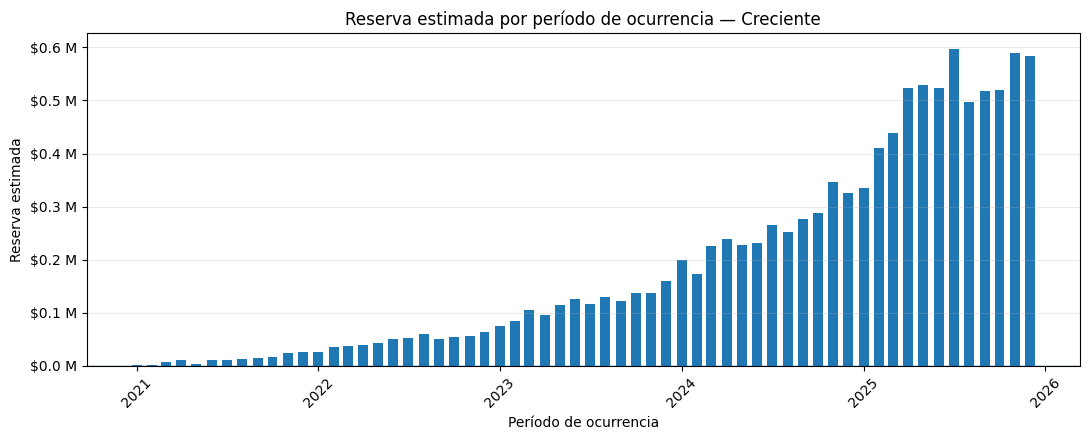

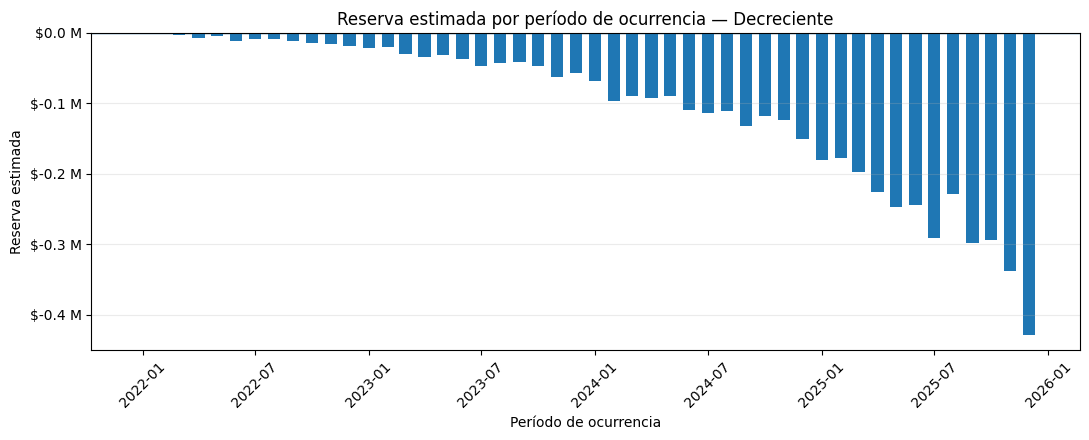

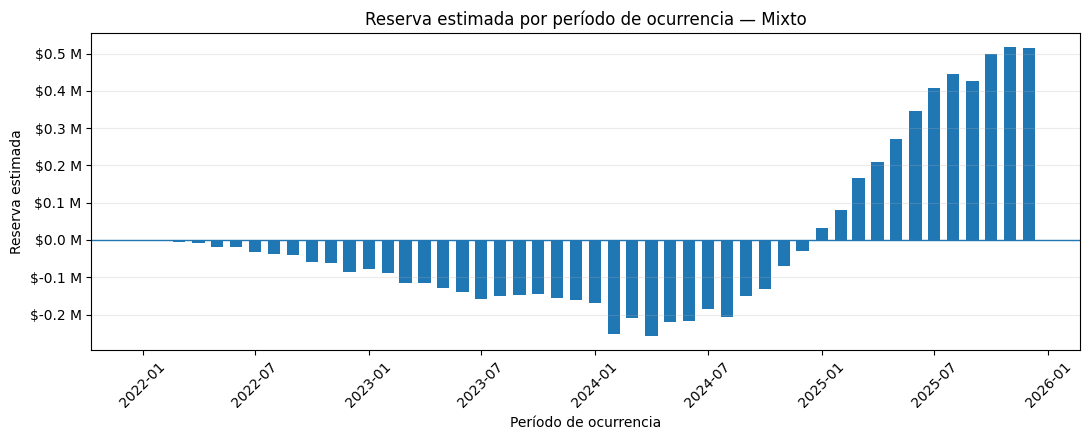

In [32]:
currency_millions = FuncFormatter(
    lambda x, _: f"${x / 1_000_000:,.1f} M"
)

for scenario, valuation in final_valuations.items():
    results = valuation["results"].copy()
    results["accident_period_ts"] = results["accident_period"].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(
        results["accident_period_ts"],
        results["reserve"],
        width=20,
    )
    ax.axhline(0, linewidth=1)

    ax.set_title(
        f"Reserva estimada por período de ocurrencia — {scenario.capitalize()}"
    )
    ax.set_xlabel("Período de ocurrencia")
    ax.set_ylabel("Reserva estimada")
    ax.yaxis.set_major_formatter(currency_millions)
    ax.grid(axis="y", alpha=0.25)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
reserve_composition = []

for scenario, valuation in final_valuations.items():

    results = valuation["results"]

    positive_reserve = results.loc[
        results["reserve"] > 0,
        "reserve",
    ].sum()

    negative_reserve = results.loc[
        results["reserve"] < 0,
        "reserve",
    ].sum()

    reserve_composition.append(
        {
            "scenario": scenario,
            "positive_cohorts": int(
                (results["reserve"] > 0).sum()
            ),
            "negative_cohorts": int(
                (results["reserve"] < 0).sum()
            ),
            "positive_reserve": positive_reserve,
            "negative_reserve": negative_reserve,
            "net_reserve": results["reserve"].sum(),
            "gross_movement": results["reserve"].abs().sum(),
        }
    )

reserve_composition = pd.DataFrame(reserve_composition)

display(
    reserve_composition.style.hide(axis="index").format(
        {
            "positive_reserve": "${:,.0f}",
            "negative_reserve": "${:,.0f}",
            "net_reserve": "${:,.0f}",
            "gross_movement": "${:,.0f}",
        }
    )
)

scenario,positive_cohorts,negative_cohorts,positive_reserve,negative_reserve,net_reserve,gross_movement
creciente,60,0,"$11,241,642",$0,"$11,241,642","$11,241,642"
decreciente,0,48,$0,"$-5,030,939","$-5,030,939","$5,030,939"
mixto,12,36,"$3,917,977","$-4,051,947","$-133,970","$7,969,924"


### Interpretación de la composición

La descomposición por cohorte permite distinguir entre la reserva neta y el
movimiento de desarrollo subyacente.

En el escenario **creciente**, las 60 cohortes inmaduras presentan reserva
positiva. Por ello, la reserva neta y el movimiento bruto coinciden en
aproximadamente $11.24 millones. El resultado refleja desarrollo pendiente
hacia niveles superiores de Loss Incurred.

En el escenario **decreciente**, las 48 cohortes inmaduras presentan reserva
negativa. La estimación de aproximadamente -$5.03 millones representa una
liberación esperada, consistente con un patrón en el que el Loss Incurred
observado disminuye conforme las cohortes alcanzan madurez.

El escenario **mixto** presenta el resultado más relevante desde el punto de
vista de agregación. Aunque la reserva neta es únicamente de aproximadamente
-$0.13 millones, existen 12 cohortes con $3.92 millones de desarrollo positivo
y 36 cohortes con -$4.05 millones de desarrollo negativo.

En términos absolutos, estas cohortes representan aproximadamente $7.97
millones de movimiento bruto:

$$
\sum_i |\widehat{R}_i| \approx 7.97\text{ millones}.
$$

Por tanto, la reserva neta cercana a cero no debe interpretarse como ausencia
de desarrollo pendiente. Es consecuencia de la compensación entre cohortes
situadas en las fases creciente y decreciente del patrón mixto.

Este resultado también muestra por qué el análisis agregado de la reserva debe
complementarse con su distribución por período de ocurrencia.

## 5. Diagnóstico contra la verdad simulada

Una vez concluida y congelada la valuación, el diseño experimental permite
comparar las estimaciones con el Loss Incurred efectivamente observado en
`dev_M`.

Esta información representa la **verdad simulada** y no fue utilizada para
ajustar los factores ni para generar las predicciones de las cohortes
inmaduras.

Para cada cohorte se define:

$$
R_i^{real} = U_i^{real} - LI_i^{obs}
$$

y el error de reserva como:

$$
E_i^{R} =
\widehat{R}_i - R_i^{real}.
$$

Equivalentemente:

$$
E_i^{R} =
\widehat{U}_i-U_i^{real}.
$$

Esta evaluación no forma parte de la selección de modelos. Su objetivo es
cuantificar, dentro del experimento simulado, la precisión de la valuación
final obtenida con el método previamente seleccionado.

In [34]:
final_diagnostics = {}

for scenario, valuation in final_valuations.items():

    results = valuation["results"].copy()

    revealed = reveal_targets(
        predictions=results,
        df=scenario_data[scenario],
        scenario=scenario,
    )

    revealed["real_reserve"] = (
        revealed["target_amount"]
        - revealed["observed_li"]
    )

    revealed["reserve_error"] = (
        revealed["reserve"]
        - revealed["real_reserve"]
    )

    revealed["absolute_reserve_error"] = (
        revealed["reserve_error"].abs()
    )

    final_diagnostics[scenario] = revealed

In [35]:
diagnostic_summary = []

for scenario, data in final_diagnostics.items():

    estimated_reserve = data["reserve"].sum()
    real_reserve = data["real_reserve"].sum()

    diagnostic_summary.append(
        {
            "scenario": scenario,
            "estimated_reserve": estimated_reserve,
            "real_reserve": real_reserve,
            "reserve_error": (
                estimated_reserve - real_reserve
            ),
            "absolute_reserve_error": abs(
                estimated_reserve - real_reserve
            ),
            "ultimate_mae": data[
                "absolute_reserve_error"
            ].mean(),
            "ultimate_rmse": np.sqrt(
                np.mean(data["reserve_error"] ** 2)
            ),
        }
    )

diagnostic_summary = pd.DataFrame(diagnostic_summary)

display(
    diagnostic_summary.style.hide(axis="index").format(
        {
            "estimated_reserve": "${:,.0f}",
            "real_reserve": "${:,.0f}",
            "reserve_error": "${:,.0f}",
            "absolute_reserve_error": "${:,.0f}",
            "ultimate_mae": "${:,.0f}",
            "ultimate_rmse": "${:,.0f}",
        }
    )
)

scenario,estimated_reserve,real_reserve,reserve_error,absolute_reserve_error,ultimate_mae,ultimate_rmse
creciente,"$11,241,642","$11,005,479","$236,163","$236,163","$15,457","$21,015"
decreciente,"$-5,030,939","$-5,309,903","$278,964","$278,964","$17,435","$21,379"
mixto,"$-133,970","$-348,674","$214,704","$214,704","$19,754","$24,128"


### Resultados del diagnóstico final

La comparación contra la verdad simulada muestra que la metodología seleccionada
produce estimaciones cercanas al desarrollo efectivamente observado a madurez.

En el escenario **creciente**, la reserva estimada fue de aproximadamente
$11.24 millones frente a una reserva real de $11.01 millones, generando una
sobreestimación agregada cercana a $0.24 millones.

En el escenario **decreciente**, la estimación fue de aproximadamente
-$5.03 millones frente a una reserva real de -$5.31 millones. En este caso,
la metodología estima correctamente la existencia de una liberación de Loss
Incurred, aunque su magnitud resulta aproximadamente $0.28 millones menor que
la observada posteriormente.

En el escenario **mixto**, la reserva estimada fue cercana a -$0.13 millones,
mientras que la reserva real fue aproximadamente -$0.35 millones. El error
agregado fue de aproximadamente $0.21 millones.

La interpretación mediante errores relativos de reserva no resulta apropiada
para este último escenario, debido a que tanto la reserva estimada como la real
son pequeñas en términos netos como consecuencia de la compensación entre
cohortes con desarrollo positivo y negativo.

A nivel de cohorte, los valores de MAE y RMSE permanecen en magnitudes similares
entre los tres escenarios. Esto sugiere que el reducido valor neto de la reserva
del escenario mixto no implica ausencia de error ni ausencia de desarrollo, sino
principalmente un efecto de agregación.

## 6. Resumen final

La siguiente tabla concentra los principales resultados de la valuación y del diagnóstico ex post para facilitar la comparación entre escenarios.

In [36]:
final_report = (
    valuation_summary[
        [
            "scenario",
            "n_immature",
            "observed_li",
            "estimated_ultimate",
            "reserve",
        ]
    ]
    .merge(
        diagnostic_summary[
            [
                "scenario",
                "real_reserve",
                "reserve_error",
                "ultimate_mae",
                "ultimate_rmse",
            ]
        ],
        on="scenario",
        how="left",
    )
)

final_report.insert(
    1,
    "dev_M",
    final_report["scenario"].map(
        {
            scenario: config.dev_M
            for scenario, config in SCENARIO_CONFIGS.items()
        }
    ),
)

final_report.insert(
    2,
    "selected_method",
    "VW_all_none",
)

display(
    final_report.style.hide(axis="index").format(
        {
            "observed_li": "${:,.0f}",
            "estimated_ultimate": "${:,.0f}",
            "reserve": "${:,.0f}",
            "real_reserve": "${:,.0f}",
            "reserve_error": "${:,.0f}",
            "ultimate_mae": "${:,.0f}",
            "ultimate_rmse": "${:,.0f}",
        }
    )
)

scenario,dev_M,selected_method,n_immature,observed_li,estimated_ultimate,reserve,real_reserve,reserve_error,ultimate_mae,ultimate_rmse
creciente,60,VW_all_none,60,"$71,564,980","$82,806,623","$11,241,642","$11,005,479","$236,163","$15,457","$21,015"
decreciente,48,VW_all_none,48,"$72,034,997","$67,004,058","$-5,030,939","$-5,309,903","$278,964","$17,435","$21,379"
mixto,48,VW_all_none,48,"$68,608,523","$68,474,553","$-133,970","$-348,674","$214,704","$19,754","$24,128"


## 7. Conclusiones

El proyecto desarrolló un ejercicio completo de estimación de reservas de
Loss Incurred bajo tres estructuras de desarrollo: creciente, decreciente y
mixta.

A partir de bases mensuales simuladas se construyeron triángulos de desarrollo,
se definieron horizontes de madurez de 60 meses para el escenario creciente y
48 meses para los escenarios decreciente y mixto, y se implementó un esquema
de backtesting temporal para comparar distintas metodologías bajo condiciones
consistentes de información disponible.

La evaluación histórica permitió seleccionar `VW_all_none` como método final
para los tres escenarios. La selección se realizó exclusivamente a partir del
backtesting y permaneció fija antes de ejecutar la valuación final.

En la fecha de valuación `2025-12`, el método produjo los siguientes resultados:

- **Creciente:** reserva estimada de aproximadamente $11.24 millones.
- **Decreciente:** reserva estimada de aproximadamente -$5.03 millones.
- **Mixto:** reserva neta estimada de aproximadamente -$0.13 millones.

Los signos de las reservas son consistentes con los patrones de desarrollo
simulados. El escenario creciente requiere reconocimiento adicional de Loss
Incurred, mientras que el escenario decreciente genera una liberación esperada.
En el escenario mixto coexisten ambos comportamientos.

Particularmente, la reserva neta reducida del escenario mixto no representa
ausencia de desarrollo. Las cohortes presentan aproximadamente $3.92 millones
de desarrollo positivo y -$4.05 millones de desarrollo negativo, equivalentes
a cerca de $7.97 millones de movimiento bruto que se compensan al agregarse.

Como diagnóstico exclusivamente experimental, las estimaciones finales se
compararon posteriormente con la verdad simulada a madurez. Los errores
agregados de reserva fueron aproximadamente $0.24 millones, $0.28 millones y
$0.21 millones para los escenarios creciente, decreciente y mixto,
respectivamente. Esta información no intervino en el ajuste ni en la selección
del método.

### Supuestos y limitaciones

Los resultados deben interpretarse dentro del diseño del experimento.

En primer lugar, las bases fueron generadas mediante patrones explícitos de
desarrollo. Por ello, los métodos tradicionales de desarrollo cuentan con una
ventaja estructural dentro de esta simulación y los resultados no permiten
concluir que sean superiores de forma general a los modelos GLM o de machine
learning en bases reales.

En segundo lugar, se supone que los horizontes `dev_M` representan
adecuadamente la madurez del Loss Incurred y que la experiencia histórica
utilizada para estimar los factores de desarrollo continúa siendo representativa
de las cohortes pendientes.

El diseño del backtesting también impone una limitación sobre las edades más
jóvenes. Debido a que el target solo puede evaluarse una vez alcanzado `dev_M`,
algunas edades tempranas presentes en la valuación final no pudieron ser
evaluadas directamente en las ventanas históricas de backtesting. Por tanto,
la valuación final de dichas edades implica una extrapolación de la estructura
de desarrollo estimada con las cohortes maduras disponibles.

Finalmente, la estimación realizada es determinista. El proyecto evalúa el
error predictivo mediante backtesting, pero no construye una distribución
probabilística de la reserva ni cuantifica explícitamente la incertidumbre
alrededor de la estimación puntual.

En conjunto, el ejercicio muestra la importancia de separar claramente la
información observable, la selección de modelos, la valuación final y la
revelación posterior de resultados. Esta separación permite evaluar métodos de
reserva evitando fuga de información y manteniendo una comparación temporal
coherente.